In [4]:
import pandas as pd

# Load the CSV files
first_file_path = '/Users/ds39/Documents/Sunny/MAVE/RD/concentration/Alltargeton_HDRvectors.csv'
second_file_path = '/Users/ds39/Downloads/AllMaxiPreps.csv'

# Read the CSV files
first_df = pd.read_csv(first_file_path)
second_df = pd.read_csv(second_file_path)

# Display the column names to confirm before merging
print("First file columns:", first_df.columns)
print("Second file columns:", second_df.columns)

# Merge the two DataFrames on the common column
merged_df = pd.merge(first_df, second_df[['HDR Vector Name', 'HDR Vector Date Produced']], 
                     left_on='Hdr Vector Lot', right_on='HDR Vector Name', how='left')

# Rename the column 'HDR Vector Date Produced' to 'Date' to match your requirement
merged_df.rename(columns={'HDR Vector Date Produced': 'Date'}, inplace=True)

# Drop the unnecessary 'HDR Vector Name' column after merging
merged_df.drop(columns=['HDR Vector Name'], inplace=True)

# Display the first few rows of the updated DataFrame to confirm
print(merged_df.head())

# Save the updated DataFrame to a new CSV file (or overwrite the existing file if desired)
output_file_path = '/Users/ds39/Documents/Sunny/MAVE/RD/concentration/Updated_Alltargeton_HDRvectors.csv'
merged_df.to_csv(output_file_path, index=False)


First file columns: Index(['Targeton Name', 'Gene', 'O/S?', 'WT Vector Lot', 'Hdr Vector Lot',
       'Nanodrop (ng/ul)', 'A260/A280', 'A260/A230', 'Qubit Re-quant (ng/ul)',
       'Qubit (ng/ul)', 'TotalYield_Qubit (ug)', 'Yield_status', 'Date'],
      dtype='object')
Second file columns: Index(['Programme', 'Lab', 'Process Name Gibson and Maxi', 'Targeton Name',
       'HDR Vector Name', 'HDR Vector Date Produced', 'HDR Vector Name.1'],
      dtype='object')
  Targeton Name   Gene O/S? WT Vector Lot Hdr Vector Lot  Nanodrop (ng/ul)  \
0          AJQR  BRCA2  NaN   AJQR_wtv135    AJQR_hdr635            6162.0   
1          AMSJ  RPS19  NaN   AMSJ_wtv484    AMSJ_hdr394            1173.6   
2          AXFG  SMC1A  NaN   AXFG_wtv389    AXFG_hdr500            4360.0   
3          BACK  BRCA2    Y   BACK_wtv592    BACK_hdr710             725.5   
4          BBAI   CTCF  NaN   BBAI_WTV339    BBAI_hdr412             929.8   

   A260/A280  A260/A230  Qubit Re-quant (ng/ul) Qubit (ng/ul)  \
0

/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_22895/2370501950.py:9: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


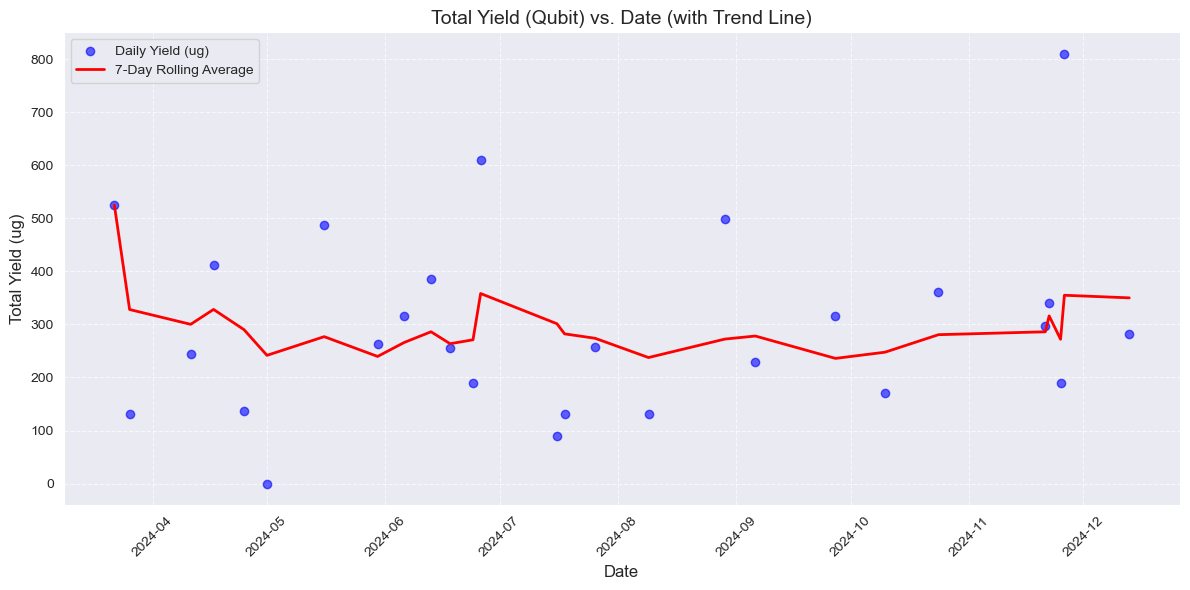

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = '/Users/ds39/Documents/Sunny/MAVE/RD/concentration/Updated_Alltargeton_HDRvectors.csv'
df = pd.read_csv(file_path)

# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop rows with missing or invalid dates
df_cleaned = df.dropna(subset=['Date', 'TotalYield_Qubit (ug)'])

# Aggregate by date (mean of TotalYield_Qubit per day)
df_grouped = df_cleaned.groupby('Date')['TotalYield_Qubit (ug)'].mean().reset_index()

# Calculate a rolling average (7-day window) for smoothing
df_grouped['Rolling_Avg'] = df_grouped['TotalYield_Qubit (ug)'].rolling(window=7, min_periods=1).mean()

# Plotting the improved graph
plt.figure(figsize=(12, 6))
plt.scatter(df_grouped['Date'], df_grouped['TotalYield_Qubit (ug)'], color='blue', alpha=0.6, label='Daily Yield (ug)')
plt.plot(df_grouped['Date'], df_grouped['Rolling_Avg'], color='red', linewidth=2, label='7-Day Rolling Average')
plt.title('Total Yield (Qubit) vs. Date (with Trend Line)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Yield (ug)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_22895/3755165769.py:10: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


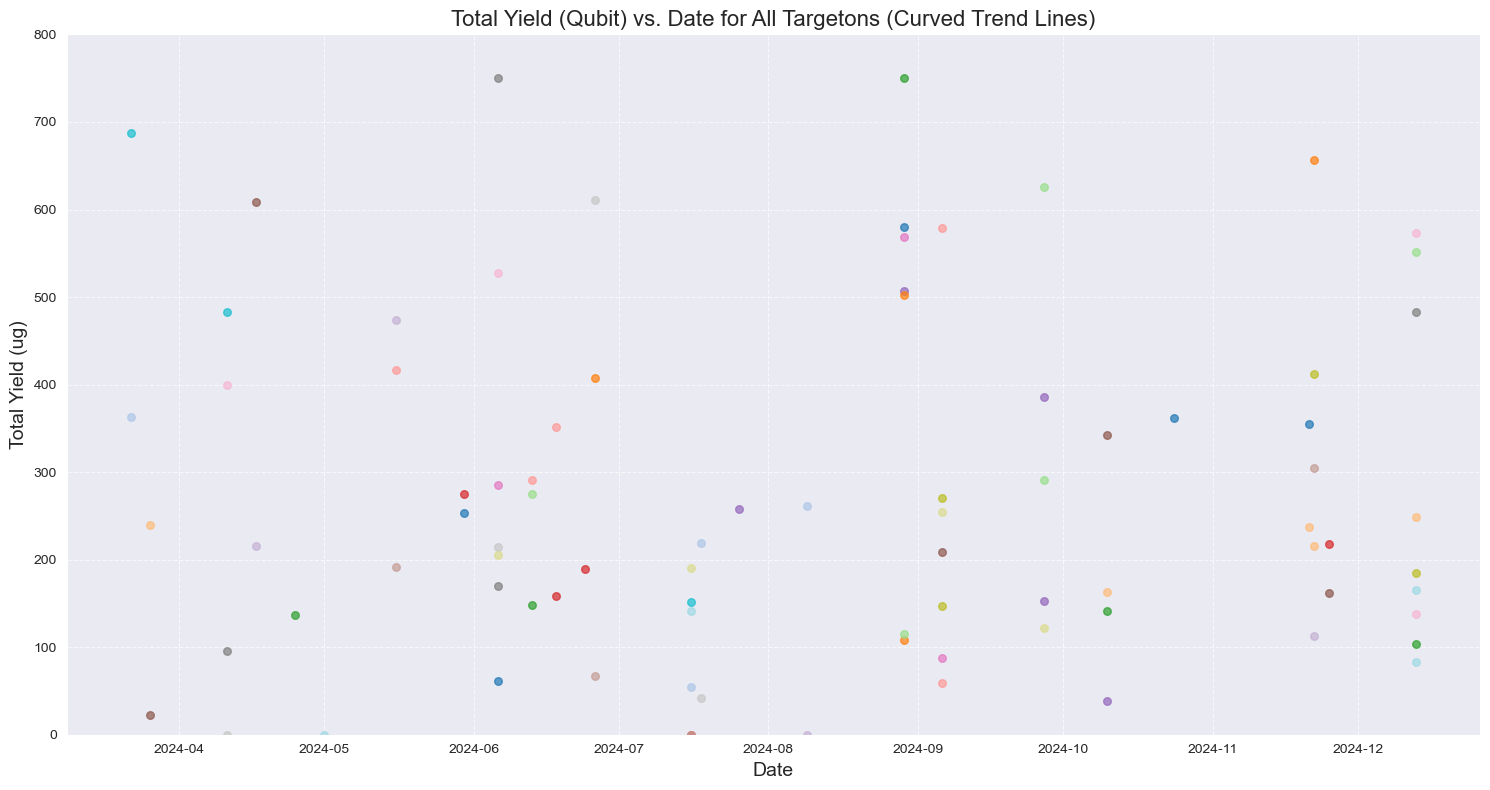

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the uploaded CSV file
file_path = '/Users/ds39/Documents/Sunny/MAVE/RD/concentration/Updated_Alltargeton_HDRvectors.csv'
df = pd.read_csv(file_path)

# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop rows with missing or invalid dates or missing 'TotalYield_Qubit (ug)'
df_cleaned = df.dropna(subset=['Date', 'TotalYield_Qubit (ug)', 'Targeton Name'])

# Check the unique Targetons in the file
unique_targetons = df_cleaned['Targeton Name'].unique()

# Prepare the plot
plt.figure(figsize=(15, 8))
colors = plt.cm.tab20.colors  # A colormap with 20 distinct colors

# Plot each Targeton separately with individual dots and polynomial trend lines
for i, targeton in enumerate(unique_targetons):
    targeton_df = df_cleaned[df_cleaned['Targeton Name'] == targeton]
    targeton_df = targeton_df.sort_values(by='Date')

    # Plot individual dots
    plt.scatter(targeton_df['Date'], targeton_df['TotalYield_Qubit (ug)'], 
                label=targeton, color=colors[i % len(colors)], alpha=0.7, s=30)
    
    # Polynomial regression (degree 3 for curved fit)
    X = targeton_df['Date'].map(pd.Timestamp.toordinal).values.reshape(-1, 1)
    y = targeton_df['TotalYield_Qubit (ug)'].values

    if len(X) > 3:  # Only fit if there are more than 3 points
        poly_model = np.poly1d(np.polyfit(X.flatten(), y, 3))
        X_range = np.linspace(X.min(), X.max(), 200)
        y_pred = poly_model(X_range)
        plt.plot(pd.to_datetime(X_range, origin='julian', unit='D'), y_pred, color=colors[i % len(colors)], lw=2)

# Format the plot
plt.title('Total Yield (Qubit) vs. Date for All Targetons (Curved Trend Lines)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Total Yield (ug)', fontsize=14)
plt.ylim(0, 800)  # Set y-axis limit to 0 - 800 µg
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



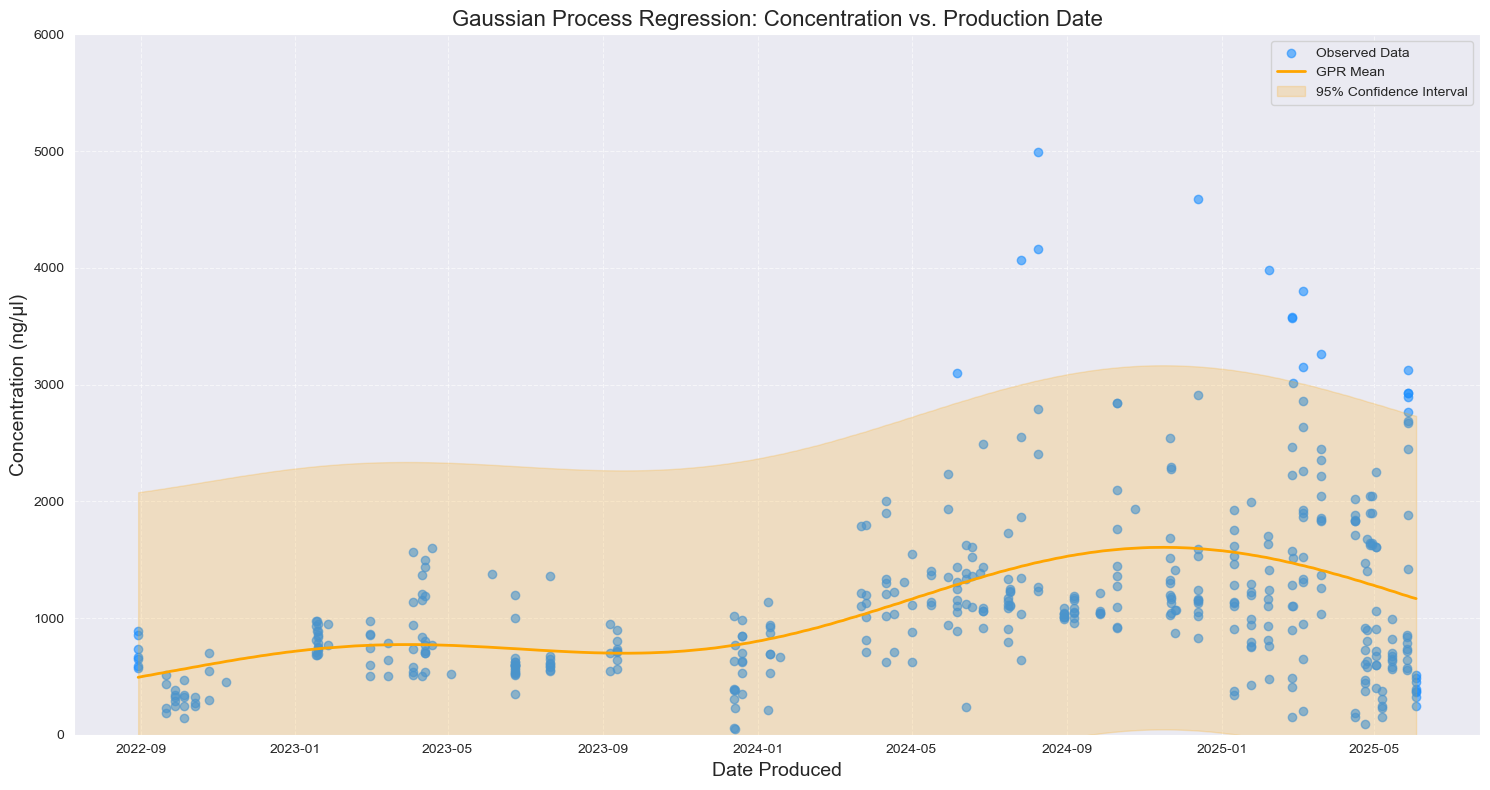

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from datetime import datetime

# Load data
file_path = '/Users/ds39/Documents/Sunny/MAVE/RD_projects/Benchling_SelectedTables/hdr_vector_lot_raw.csv'
df = pd.read_csv(file_path)

# Clean and convert columns
df['date_produced'] = pd.to_datetime(df['date_produced'], errors='coerce')
df['concentration_auto'] = pd.to_numeric(df['concentration_auto'], errors='coerce')

# ✅ Filter rows: non-null date, non-null concentration, > 50
df_clean = df.dropna(subset=['date_produced', 'concentration_auto'])
df_clean = df_clean[df_clean['concentration_auto'] > 50]

# Sort by date
df_clean = df_clean.sort_values(by='date_produced')

# Prepare features
X = df_clean['date_produced'].map(pd.Timestamp.toordinal).values.reshape(-1, 1)
y = df_clean['concentration_auto'].values

# Gaussian Process model
kernel = RBF(length_scale=30.0) + WhiteKernel(noise_level=10.0)
gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
gpr.fit(X, y)

# Predict over date range
X_pred = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_pred, y_std = gpr.predict(X_pred, return_std=True)
X_pred_dates = [datetime.fromordinal(int(x)) for x in X_pred.flatten()]

# Plot
plt.figure(figsize=(15, 8))
plt.scatter(df_clean['date_produced'], df_clean['concentration_auto'],
            color='dodgerblue', alpha=0.6, label='Observed Data')
plt.plot(X_pred_dates, y_pred, color='orange', lw=2, label='GPR Mean')
plt.fill_between(X_pred_dates, y_pred - 1.96*y_std, y_pred + 1.96*y_std,
                 color='orange', alpha=0.2, label='95% Confidence Interval')

# ✅ Updated formatting
plt.title('Gaussian Process Regression: Concentration vs. Production Date', fontsize=16)
plt.xlabel('Date Produced', fontsize=14)
plt.ylabel('Concentration (ng/µl)', fontsize=14)
plt.ylim(0, 6000)  # ✅ Set y-axis max to 5000
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.preprocessing import StandardScaler

# === CONFIGURATION ===
file_path = '/Users/ds39/Documents/Sunny/MAVE/RD_projects/concentration/250402_AllTargetonlist_quantification_revalues.csv'

# === HELPERS ===
def sanitize_filename(name):
    """Sanitize filenames to avoid invalid characters."""
    return re.sub(r'[\/:*?"<>| ]', '_', name)

# === LOAD DATA ===
df = pd.read_csv(file_path)

# Select numeric columns only
numeric_df = df.select_dtypes(include=[np.number])

# Drop columns with too many NaNs
numeric_df = numeric_df.dropna(thresh=10, axis=1)

# Drop rows with any NaN in numeric columns
numeric_df = numeric_df.dropna()

# Filter: keep only rows where all numeric values > 0
numeric_df = numeric_df[(numeric_df > 0).all(axis=1)]

# === OUTPUT DIRECTORY ===
base_dir = os.path.dirname(file_path)
output_dir = os.path.join(base_dir, 'GausianProcessingRegression')
os.makedirs(output_dir, exist_ok=True)

# === GPR ANALYSIS ===
for i, x_col in enumerate(numeric_df.columns):
    for j, y_col in enumerate(numeric_df.columns):
        if i >= j:
            continue  # Skip duplicates and self-pairs

        X = numeric_df[[x_col]].values
        y = numeric_df[y_col].values

        # Normalize X for better GPR performance
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Fit Gaussian Process Regressor
        kernel = RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)
        gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
        gpr.fit(X_scaled, y)

        # Predict
        X_pred = np.linspace(X_scaled.min(), X_scaled.max(), 300).reshape(-1, 1)
        y_pred, y_std = gpr.predict(X_pred, return_std=True)

        # Inverse transform X_pred for plotting
        X_orig = scaler.inverse_transform(X_pred)

        # Plot
        plt.figure(figsize=(10, 6))
        plt.scatter(X, y, alpha=0.5, label='Observed Data')
        plt.plot(X_orig, y_pred, color='darkorange', label='GPR Mean')
        plt.fill_between(X_orig.flatten(), y_pred - 1.96*y_std, y_pred + 1.96*y_std,
                         color='orange', alpha=0.2, label='95% Confidence')
        plt.title(f'GPR: {y_col} ~ {x_col}')
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend()
        plt.tight_layout()

        # Save plot
        filename = f"GPR_{sanitize_filename(y_col)}_vs_{sanitize_filename(x_col)}.png"
        full_path = os.path.join(output_dir, filename)
        plt.savefig(full_path, dpi=300)
        plt.close()

print(f"✅ All GPR plots saved to: {output_dir}")
